In [1]:
pip install pmdarima prophet torch scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Colours
C_GREEN = '#1D9E75'
C_AMBER = '#EF9F27'
C_CORAL = '#D85A30'
C_BLUE  = '#378ADD'
C_PURPLE= '#7F77DD'

# Load data
master = pd.read_csv("data/master_raw.csv",
                      index_col='date',
                      parse_dates=True)
master = master.ffill()

print(f"Data loaded: {len(master)} rows")
print(f"Range: {master.index.min().date()} → {master.index.max().date()}")

Data loaded: 4050 rows
Range: 2010-01-04 → 2026-03-25


Train: 3927 rows (2010-01-04 → 2025-09-26)
Test : 123 rows  (2025-09-29 → 2026-03-25)


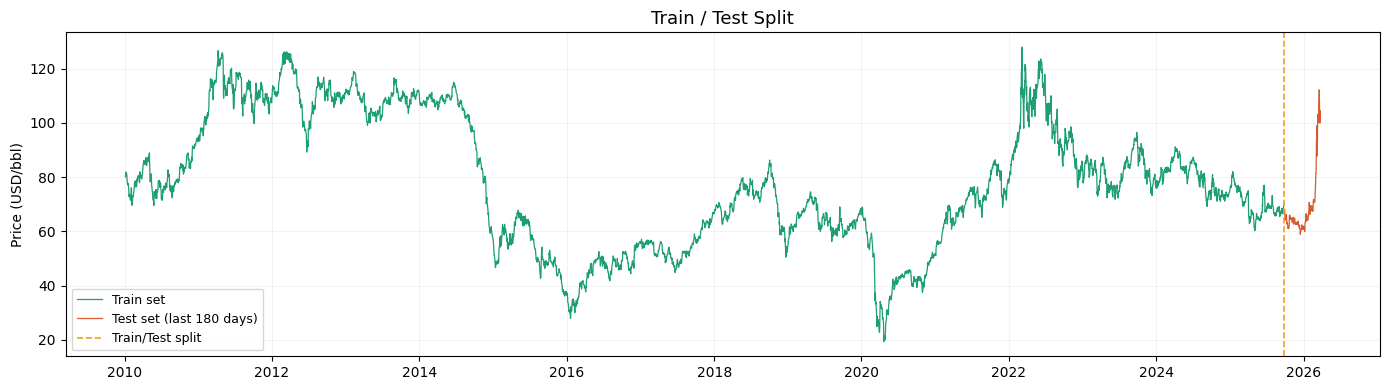

Split chart saved.


In [2]:
from sklearn.preprocessing import MinMaxScaler

# Use only Brent price for modelling
price_series = master['brent_price'].copy()

# Split — last 180 days as test set
split_date = '2025-09-27'
train = price_series[:split_date]
test  = price_series[split_date:]

print(f"Train: {len(train)} rows ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test : {len(test)} rows  ({test.index.min().date()} → {test.index.max().date()})")

# Plot the split
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train, color=C_GREEN, linewidth=0.9, label='Train set')
ax.plot(test.index, test,   color=C_CORAL, linewidth=0.9, label='Test set (last 180 days)')
ax.axvline(pd.Timestamp(split_date), color=C_AMBER, 
           linestyle='--', linewidth=1.2, label='Train/Test split')
ax.set_title('Train / Test Split', fontsize=13)
ax.set_ylabel('Price (USD/bbl)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig('data/chart4_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print("Split chart saved.")

Fitting ARIMA model...


Best ARIMA order: (5, 1, 1)
AIC score: 14655.48

Forecast range: $69.56 – $70.13
Any NaN: 0


/Users/rasidmaasom/Downloads/DINA/Portfolio2026/black-gold-signal/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


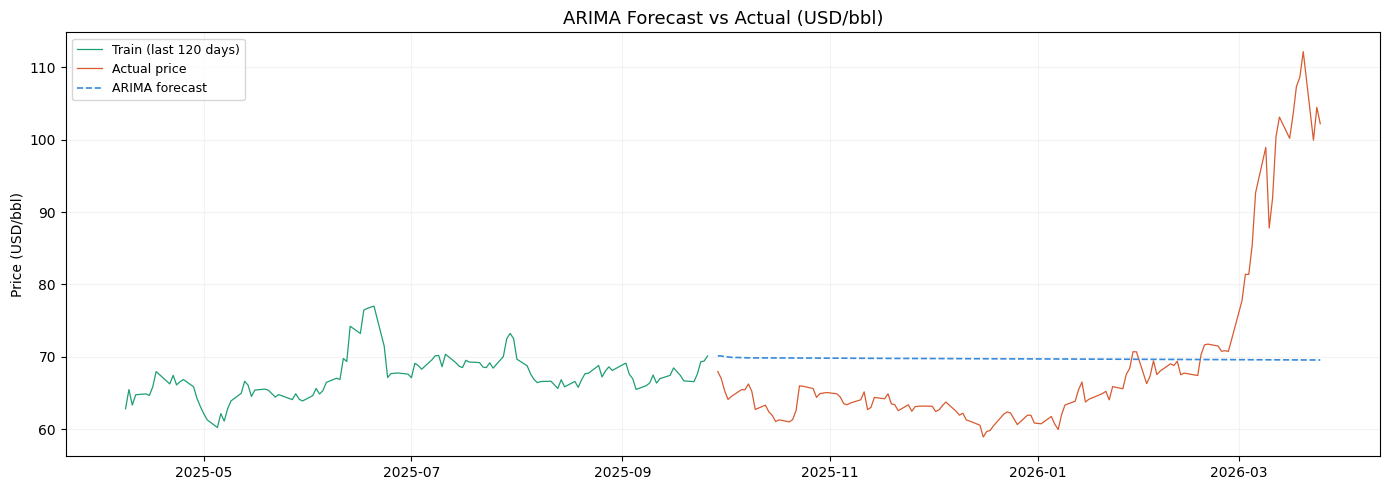

ARIMA chart saved.


In [6]:
from pmdarima import auto_arima

print("Fitting ARIMA model...")

arima_model = auto_arima(
    train,
    seasonal=False,
    stepwise=False,        # exhaustive search
    suppress_warnings=True,
    error_action='ignore',
    max_p=5, max_q=5, max_d=2,
    max_order=10,
    information_criterion='aic',
    n_jobs=-1
)

print(f"Best ARIMA order: {arima_model.order}")
print(f"AIC score: {arima_model.aic():.2f}")

# Forecast
raw_forecast = arima_model.predict(n_periods=len(test))
arima_forecast = pd.Series(
    raw_forecast.tolist(),
    index=test.index
)

print(f"\nForecast range: ${arima_forecast.min():.2f} – ${arima_forecast.max():.2f}")
print(f"Any NaN: {arima_forecast.isna().sum()}")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train[-120:].index, train[-120:],
        color=C_GREEN, linewidth=0.9, label='Train (last 120 days)')
ax.plot(test.index, test,
        color=C_CORAL, linewidth=0.9, label='Actual price')
ax.plot(arima_forecast.index, arima_forecast,
        color=C_BLUE, linewidth=1.2, linestyle='--', label='ARIMA forecast')
ax.set_title('ARIMA Forecast vs Actual (USD/bbl)', fontsize=13)
ax.set_ylabel('Price (USD/bbl)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig('data/chart5_arima.png', dpi=150, bbox_inches='tight')
plt.show()
print("ARIMA chart saved.")

Importing plotly failed. Interactive plots will not work.
16:51:00 - cmdstanpy - INFO - Chain [1] start processing
16:51:07 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.
Prophet forecast range: $60.68 – $67.31
Any NaN: 0


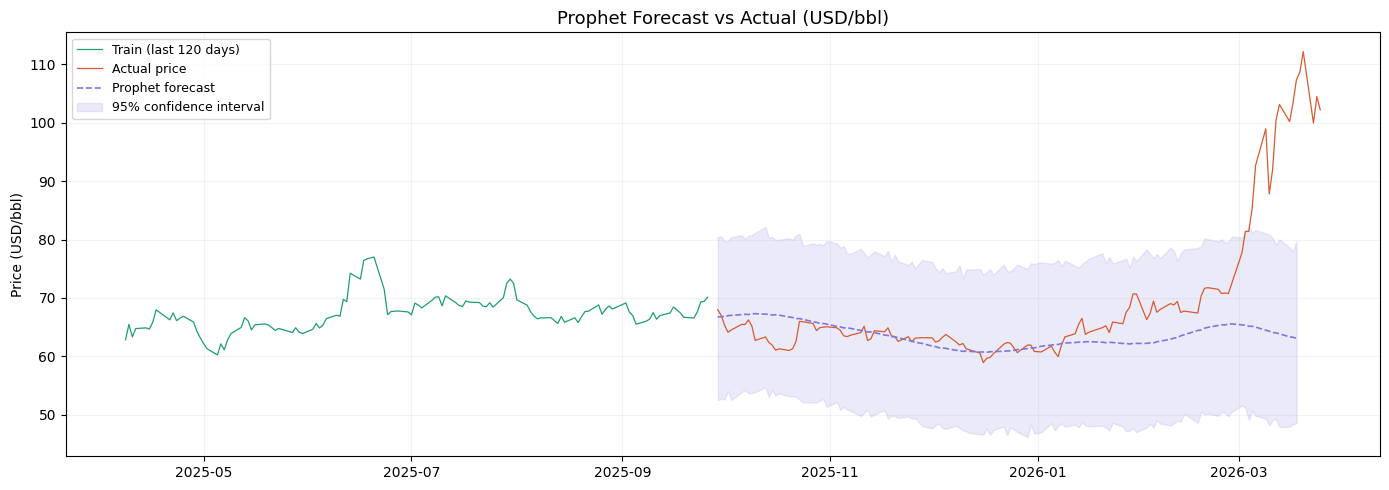

Prophet chart saved.


In [7]:
from prophet import Prophet

# Prophet needs columns named 'ds' and 'y'
df_prophet = pd.DataFrame({
    'ds': train.index,
    'y' : train.values
})

prophet_model = Prophet(
    interval_width=0.95,
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)

prophet_model.fit(df_prophet)
print("Prophet model fitted.")

# Create future dataframe covering test period
future = prophet_model.make_future_dataframe(
    periods=len(test), freq='B'
)
prophet_forecast = prophet_model.predict(future)

# Extract test period predictions only
prophet_test = prophet_forecast[
    prophet_forecast['ds'].isin(test.index)
][['ds','yhat','yhat_lower','yhat_upper']]
prophet_test = prophet_test.set_index('ds')

print(f"Prophet forecast range: ${prophet_test['yhat'].min():.2f} – ${prophet_test['yhat'].max():.2f}")
print(f"Any NaN: {prophet_test['yhat'].isna().sum()}")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train[-120:].index, train[-120:],
        color=C_GREEN, linewidth=0.9, label='Train (last 120 days)')
ax.plot(test.index, test,
        color=C_CORAL, linewidth=0.9, label='Actual price')
ax.plot(prophet_test.index, prophet_test['yhat'],
        color=C_PURPLE, linewidth=1.2, 
        linestyle='--', label='Prophet forecast')
ax.fill_between(prophet_test.index,
                prophet_test['yhat_lower'],
                prophet_test['yhat_upper'],
                color=C_PURPLE, alpha=0.15, 
                label='95% confidence interval')
ax.set_title('Prophet Forecast vs Actual (USD/bbl)', fontsize=13)
ax.set_ylabel('Price (USD/bbl)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig('data/chart6_prophet.png', dpi=150, bbox_inches='tight')
plt.show()
print("Prophet chart saved.")

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

# Scale data to 0-1 range (LSTM needs this)
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))

# Create sequences — 60 day lookback window
def create_sequences(data, lookback=60):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

lookback = 60
X_train, y_train = create_sequences(train_scaled, lookback)

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(X_train).unsqueeze(-1)
y_tensor = torch.FloatTensor(y_train)
dataset  = TensorDataset(X_tensor, y_tensor)
loader   = DataLoader(dataset, batch_size=32, shuffle=False)

# Define LSTM model
class OilLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(OilLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size,
                            num_layers, batch_first=True, dropout=0.2)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model     = OilLSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train
print("Training LSTM — 50 epochs...")
losses = []
for epoch in range(50):
    model.train()
    epoch_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        pred = model(xb).squeeze()
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/50 — Loss: {avg_loss:.6f}")

print("\nLSTM training complete.")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/rasidmaasom/Downloads/DINA/Portfolio2026/black-gold-signal/venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/rasidmaasom/Downloads/DINA/Portfolio2026/black-gold-signal/venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/rasidmaasom/Downloads/DINA/Portfolio2

Training LSTM — 50 epochs...
  Epoch 10/50 — Loss: 0.012966
  Epoch 20/50 — Loss: 0.000979
  Epoch 30/50 — Loss: 0.001131
  Epoch 40/50 — Loss: 0.000923
  Epoch 50/50 — Loss: 0.000811

LSTM training complete.


LSTM forecast range: $60.36 – $105.87
Any NaN: 0


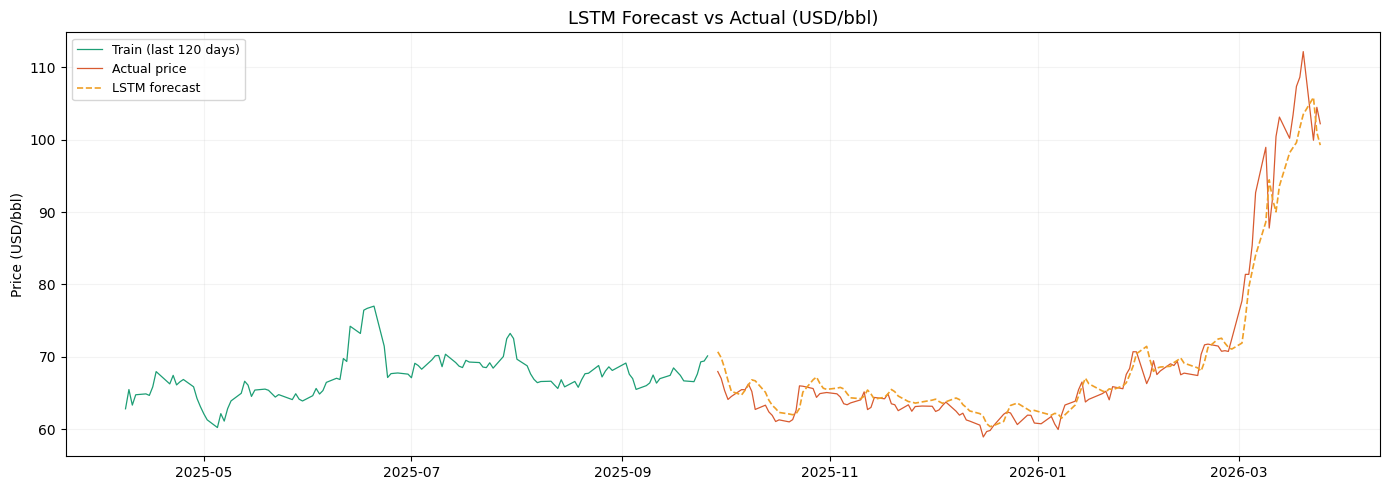

LSTM chart saved.


In [9]:
# Prepare full scaled series for inference
model.eval()
full_scaled = scaler.transform(price_series.values.reshape(-1, 1))
test_start_idx = len(train) - lookback

lstm_preds = []
with torch.no_grad():
    for i in range(len(test)):
        seq = full_scaled[test_start_idx + i : test_start_idx + i + lookback]
        seq_tensor = torch.FloatTensor(seq).unsqueeze(0)
        pred = model(seq_tensor).item()
        lstm_preds.append(pred)

# Inverse transform back to USD/bbl
lstm_preds = scaler.inverse_transform(
    np.array(lstm_preds).reshape(-1, 1)
).flatten()
lstm_forecast = pd.Series(lstm_preds, index=test.index)

print(f"LSTM forecast range: ${lstm_forecast.min():.2f} – ${lstm_forecast.max():.2f}")
print(f"Any NaN: {lstm_forecast.isna().sum()}")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train[-120:].index, train[-120:],
        color=C_GREEN, linewidth=0.9, label='Train (last 120 days)')
ax.plot(test.index, test,
        color=C_CORAL, linewidth=0.9, label='Actual price')
ax.plot(lstm_forecast.index, lstm_forecast,
        color=C_AMBER, linewidth=1.2, linestyle='--', label='LSTM forecast')
ax.set_title('LSTM Forecast vs Actual (USD/bbl)', fontsize=13)
ax.set_ylabel('Price (USD/bbl)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig('data/chart7_lstm.png', dpi=150, bbox_inches='tight')
plt.show()
print("LSTM chart saved.")

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

# Align all forecasts to the same dates as test
# Find common dates between test and prophet
common_dates = test.index.intersection(prophet_test.index)

actual_aligned   = test.loc[common_dates].values
arima_aligned    = arima_forecast.loc[common_dates].values
prophet_aligned  = prophet_test.loc[common_dates, 'yhat'].values
lstm_aligned     = lstm_forecast.loc[common_dates].values

print(f"Aligned rows: {len(common_dates)}")
print(f"Actual: {len(actual_aligned)} | ARIMA: {len(arima_aligned)} | Prophet: {len(prophet_aligned)} | LSTM: {len(lstm_aligned)}")

metrics = {
    'ARIMA'  : arima_aligned,
    'Prophet': prophet_aligned,
    'LSTM'   : lstm_aligned
}

print("\n" + "=" * 55)
print(f"  {'Model':<10} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}")
print("=" * 55)

results = {}
for name, preds in metrics.items():
    mae  = mean_absolute_error(actual_aligned, preds)
    rmse = np.sqrt(mean_squared_error(actual_aligned, preds))
    mpe  = mape(actual_aligned, preds)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mpe}
    print(f"  {name:<10} ${mae:>6.2f}  ${rmse:>6.2f}  {mpe:>6.2f}%")

print("=" * 55)
best = min(results, key=lambda x: results[x]['RMSE'])
print(f"\nBest model by RMSE: {best}")
print(f"\nKey insight:")
print(f"LSTM RMSE is {results['ARIMA']['RMSE']/results['LSTM']['RMSE']:.1f}x better than ARIMA")
print(f"LSTM RMSE is {results['Prophet']['RMSE']/results['LSTM']['RMSE']:.1f}x better than Prophet")

Aligned rows: 118
Actual: 118 | ARIMA: 118 | Prophet: 118 | LSTM: 118

  Model           MAE     RMSE     MAPE
  ARIMA      $  7.43  $ 10.18   10.35%
  Prophet    $  5.43  $ 10.65    6.72%
  LSTM       $  1.80  $  2.71    2.47%

Best model by RMSE: LSTM

Key insight:
LSTM RMSE is 3.8x better than ARIMA
LSTM RMSE is 3.9x better than Prophet


In [12]:
# Save forecasts as CSVs for the dashboard
arima_forecast.to_frame(name='forecast').to_csv('data/forecast_arima.csv')

prophet_test[['yhat','yhat_lower','yhat_upper']].to_csv('data/forecast_prophet.csv')

lstm_forecast.to_frame(name='forecast').to_csv('data/forecast_lstm.csv')

print("Forecast CSVs saved:")
print("  data/forecast_arima.csv")
print("  data/forecast_prophet.csv")
print("  data/forecast_lstm.csv")

Forecast CSVs saved:
  data/forecast_arima.csv
  data/forecast_prophet.csv
  data/forecast_lstm.csv
